### prep chai array-like

In [47]:
import pandas as pd
import yaml
from pathlib import Path

YAML_PATH = "/home/bri/pymol/EDA/static/metric_directions.yaml"
OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/germinal_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CSV_PATH =  "/home/bri/pymol/EDA/static/germinal_outputs/merged_germinal.csv"
scores_df = pd.read_csv(CSV_PATH)

scores_df.head()



,source,type,binder,KD[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_ptm,chai_constrained_per_chain_pair_iptm
0,germinal,original,0,NaN,nb_s413501_mpnn_3_PDL1,6.108293,86.742610,16.79,0.93,2.044286,...,3.668416,0.629430,0.286417,0.3117,0.2812,0.3347,"[[0.9273825883865356, 0.8894672989845276]]","[[[0.9273825883865356, 0.44341152906417847], [...","[[0.9388881325721741, 0.9319360852241516]]","[[[0.9388881325721741, 0.806764543056488], [0...."
1,germinal,original,0,NaN,nb_s80903_mpnn_4_PDL1,5.704870,87.377710,35.37,2.03,2.497436,...,2.014986,0.824976,0.615900,0.3215,0.4823,0.5713,"[[0.9228965044021606, 0.8899376392364502]]","[[[0.9228965044021606, 0.6508838534355164], [0...","[[0.9284995794296265, 0.9254387021064758]]","[[[0.9284995794296265, 0.6832306385040283], [0..."
2,germinal,original,0,NaN,nb_s185784_mpnn_4_PDL1,5.882517,87.466883,68.68,4.47,3.201563,...,2.478055,0.688911,0.410030,0.2974,0.3102,0.4039,"[[0.9310107827186584, 0.926919162273407]]","[[[0.9310107827186584, 0.7188717126846313], [0...","[[0.9230786561965942, 0.8749508857727051]]","[[[0.9230786561965942, 0.3063301742076874], [0..."
3,germinal,original,0,NaN,nb_s465730_mpnn_4_PDL1,6.592750,85.815865,132.43,7.57,3.376923,...,1.453783,0.834977,0.683534,0.3291,0.5252,0.5998,"[[0.9071958065032959, 0.8811732530593872]]","[[[0.9071958065032959, 0.6785235404968262], [0...","[[0.8953481316566467, 0.9284237623214722]]","[[[0.8953481316566467, 0.7335245609283447], [0..."
4,germinal,original,0,NaN,nb_s892360_mpnn_4_PDL1,6.833474,86.163597,81.72,4.71,3.086486,...,1.266391,0.876978,0.783194,0.4001,0.7099,0.6743,"[[0.8962238430976868, 0.884861171245575]]","[[[0.8962238430976868, 0.26031896471977234], [...","[[0.9198889136314392, 0.8923708200454712]]","[[[0.9198889136314392, 0.3899534344673157], [0..."


### prep chai array-like

In [48]:
chai_df = scores_df[['sample', 'chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']]
chai_df.to_csv(OUTPUT_DIR / 'chai_matrices.csv', index=False)

In [49]:
chai_df.head()

,sample,chai_unconstrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_ptm,chai_constrained_per_chain_pair_iptm
0,nb_s413501_mpnn_3_PDL1,"[[0.9273825883865356, 0.8894672989845276]]","[[[0.9273825883865356, 0.44341152906417847], [...","[[0.9388881325721741, 0.9319360852241516]]","[[[0.9388881325721741, 0.806764543056488], [0...."
1,nb_s80903_mpnn_4_PDL1,"[[0.9228965044021606, 0.8899376392364502]]","[[[0.9228965044021606, 0.6508838534355164], [0...","[[0.9284995794296265, 0.9254387021064758]]","[[[0.9284995794296265, 0.6832306385040283], [0..."
2,nb_s185784_mpnn_4_PDL1,"[[0.9310107827186584, 0.926919162273407]]","[[[0.9310107827186584, 0.7188717126846313], [0...","[[0.9230786561965942, 0.8749508857727051]]","[[[0.9230786561965942, 0.3063301742076874], [0..."
3,nb_s465730_mpnn_4_PDL1,"[[0.9071958065032959, 0.8811732530593872]]","[[[0.9071958065032959, 0.6785235404968262], [0...","[[0.8953481316566467, 0.9284237623214722]]","[[[0.8953481316566467, 0.7335245609283447], [0..."
4,nb_s892360_mpnn_4_PDL1,"[[0.8962238430976868, 0.884861171245575]]","[[[0.8962238430976868, 0.26031896471977234], [...","[[0.9198889136314392, 0.8923708200454712]]","[[[0.9198889136314392, 0.3899534344673157], [0..."


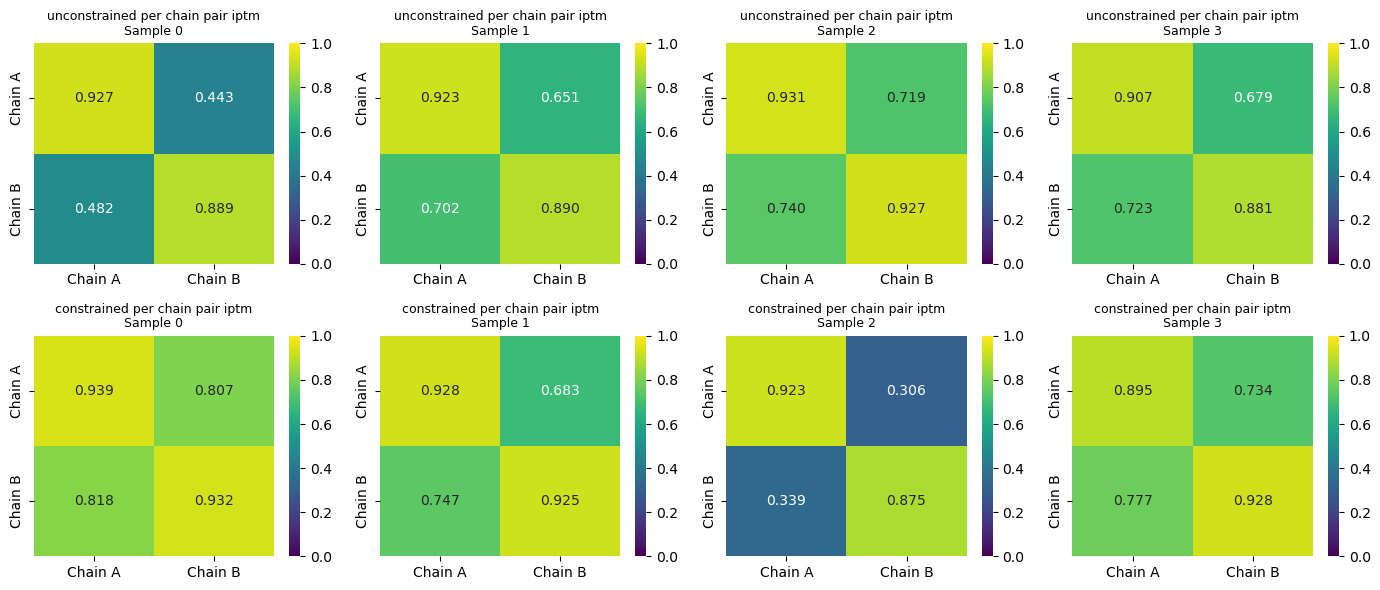

In [50]:
# Parse matrix strings from all 4 chai columns
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def parse_matrix(x):
    if pd.isna(x):
        return None
    try:
        arr = np.array(ast.literal_eval(x))
        return arr.squeeze()  # remove extra dimensions
    except:
        return None

# Apply parse_matrix to all 4 columns
ptm_cols = ['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']

for col in ptm_cols:
    chai_df[f"{col}_matrix"] = chai_df[col].apply(parse_matrix)

# Create heatmaps for first 4 samples (focusing on pair_iptm columns)
pair_cols = ['chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_pair_iptm']

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for row_idx, col in enumerate(pair_cols):
    for sample_idx in range(4):
        ax = axes[row_idx, sample_idx]
        matrix = chai_df[f"{col}_matrix"].iloc[sample_idx]
        
        if matrix is not None and isinstance(matrix, np.ndarray) and matrix.ndim == 2:
            n = matrix.shape[0]  # works for 2x2, 3x3, etc.
            labels = [f'Chain {chr(65+i)}' for i in range(n)]  # A, B, C, ...
            
            sns.heatmap(
                matrix,
                ax=ax,
                cmap='viridis',
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                vmin=0,
                vmax=1,
                annot=True,
                fmt='.3f'
            )
            
            ax.set_title(
                f'{col.replace("chai_", "").replace("_", " ")}\nSample {sample_idx}',
                fontsize=9
            )
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])


plt.tight_layout()
plt.savefig(OUTPUT_DIR /'chai_matrices_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()



In [51]:
def extract_matrix_mean(matrix):
    if matrix is None or not isinstance(matrix, np.ndarray) or matrix.ndim != 2:
        return np.nan

    n = matrix.shape[0]

    # constrained: only one interface (A-C or B-C)
    if n == 2:
        return np.mean([matrix[0, 1], matrix[1, 0]])

    # unconstrained: average C interactions with A and B
    elif n == 3:
        ac = np.mean([matrix[0, 2], matrix[2, 0]])
        bc = np.mean([matrix[1, 2], matrix[2, 1]])
        return np.mean([ac, bc])

    return np.nan

chai_df['chai_unconstrained_per_chain_iptm'] = \
    chai_df['chai_unconstrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_mean)

chai_df['chai_constrained_per_chain_iptm'] = \
    chai_df['chai_constrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_mean)


# Display summary
print("Unconstrained A-B interface mean (top 10):")
print(chai_df['chai_unconstrained_per_chain_iptm'].head(10).to_string())
print("\nConstrained A-B interface mean (top 10):")
print(chai_df['chai_constrained_per_chain_iptm'].head(10).to_string())

Unconstrained A-B interface mean (top 10):
0    0.462928
1    0.676272
2    0.729324
3    0.700904
4    0.257265
5    0.261968
6    0.242271
7    0.387655
8    0.829420
9    0.542022

Constrained A-B interface mean (top 10):
0    0.812274
1    0.715133
2    0.322705
3    0.755280
4    0.393565
5    0.688014
6    0.619771
7    0.687848
8    0.438623
9    0.452804


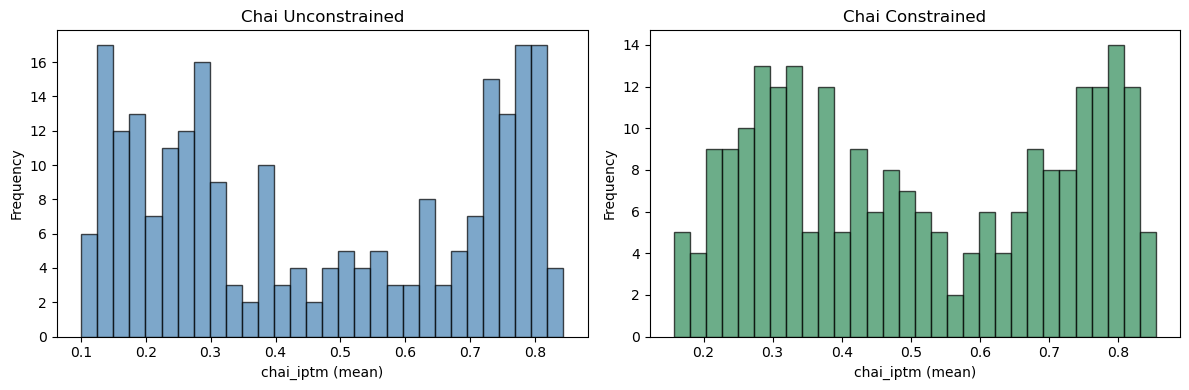

In [52]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_iptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('chai_iptm (mean)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chai Unconstrained')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_iptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('chai_iptm (mean)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Chai Constrained')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chai_ab_interface_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
# Extract mean pTM
def extract_ptm_mean(arr):
    """Extract mean of pTM array (average across both chains)"""
    if arr is None or not isinstance(arr, np.ndarray) or arr.ndim != 1:
        return np.nan
    return np.mean(arr)

# Extract mean for unconstrained pTM
chai_df['chai_unconstrained_per_chain_ptm'] = \
    chai_df['chai_unconstrained_per_chain_ptm_matrix'].apply(extract_ptm_mean)

# Extract mean for constrained pTM
chai_df['chai_constrained_per_chain_ptm'] = \
    chai_df['chai_constrained_per_chain_ptm_matrix'].apply(extract_ptm_mean)

# Display summary
print("pTM Mean Scores:")
print("\nUnconstrained pTM mean (top 10):")
print(chai_df['chai_unconstrained_per_chain_ptm'].head(10).to_string())
print("\nConstrained pTM mean (top 10):")
print(chai_df['chai_constrained_per_chain_ptm'].head(10).to_string())
print(f"\nUnconstrained pTM mean - desc stats:\n{chai_df['chai_unconstrained_per_chain_ptm'].describe()}")
print(f"\nConstrained pTM mean - desc stats:\n{chai_df['chai_constrained_per_chain_ptm'].describe()}")

pTM Mean Scores:

Unconstrained pTM mean (top 10):
0    0.908425
1    0.906417
2    0.928965
3    0.894185
4    0.890543
5    0.906802
6    0.873761
7    0.900691
8    0.931571
9    0.896960

Constrained pTM mean (top 10):
0    0.935412
1    0.926969
2    0.899015
3    0.911886
4    0.906130
5    0.928585
6    0.901555
7    0.912052
8    0.895576
9    0.877163

Unconstrained pTM mean - desc stats:
count    240.000000
mean       0.850134
std        0.116614
min        0.590242
25%        0.880712
50%        0.900537
75%        0.917230
max        0.934105
Name: chai_unconstrained_per_chain_ptm, dtype: float64

Constrained pTM mean - desc stats:
count    240.000000
mean       0.852615
std        0.110272
min        0.598472
25%        0.877581
50%        0.900480
75%        0.919075
max        0.935412
Name: chai_constrained_per_chain_ptm, dtype: float64


In [54]:
# Create df_chai_numeric with extracted mean scores 
df_chai_numeric = chai_df[['sample',
                            'chai_unconstrained_per_chain_ptm',
                            'chai_constrained_per_chain_ptm',
                            'chai_unconstrained_per_chain_iptm',
                            'chai_constrained_per_chain_iptm']].copy()

print("df_chai_numeric shape:", df_chai_numeric.shape)
print("\ndf_chai_numeric head:")
print(df_chai_numeric.head(10).to_string())
print("\ndf_chai_numeric info:")
print(df_chai_numeric.info())

# Save to CSV
df_chai_numeric.to_csv(OUTPUT_DIR / 'chai_numeric_metrics.csv', index=False)
print("\n✓ Saved to: chai_numeric_metrics.csv")

df_chai_numeric shape: (240, 5)

df_chai_numeric head:
                   sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_iptm  chai_constrained_per_chain_iptm
0  nb_s413501_mpnn_3_PDL1                          0.908425                        0.935412                           0.462928                         0.812274
1   nb_s80903_mpnn_4_PDL1                          0.906417                        0.926969                           0.676272                         0.715133
2  nb_s185784_mpnn_4_PDL1                          0.928965                        0.899015                           0.729324                         0.322705
3  nb_s465730_mpnn_4_PDL1                          0.894185                        0.911886                           0.700904                         0.755280
4  nb_s892360_mpnn_4_PDL1                          0.890543                        0.906130                           0.257265                   

In [55]:
scores_df.drop(columns=['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm'], inplace = True)
scores_df.head()

,source,type,binder,KD[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis
0,germinal,original,0,NaN,nb_s413501_mpnn_3_PDL1,6.108293,86.742610,16.79,0.93,2.044286,...,0.639892,0.935969,0.913586,0.558209,3.668416,0.629430,0.286417,0.3117,0.2812,0.3347
1,germinal,original,0,NaN,nb_s80903_mpnn_4_PDL1,5.704870,87.377710,35.37,2.03,2.497436,...,0.843225,0.901484,0.861739,0.433091,2.014986,0.824976,0.615900,0.3215,0.4823,0.5713
2,germinal,original,0,NaN,nb_s185784_mpnn_4_PDL1,5.882517,87.466883,68.68,4.47,3.201563,...,0.688911,0.865942,0.825091,0.601709,2.478055,0.688911,0.410030,0.2974,0.3102,0.4039
3,germinal,original,0,NaN,nb_s465730_mpnn_4_PDL1,6.592750,85.815865,132.43,7.57,3.376923,...,0.845215,0.907688,0.875164,0.419413,1.453783,0.834977,0.683534,0.3291,0.5252,0.5998
4,germinal,original,0,NaN,nb_s892360_mpnn_4_PDL1,6.833474,86.163597,81.72,4.71,3.086486,...,0.906872,0.931934,0.914226,0.367888,1.266391,0.876978,0.783194,0.4001,0.7099,0.6743


In [56]:
# Join scores_df with df_chai_numeric on "sample"
scores_df_extended = scores_df.merge(df_chai_numeric, on='sample', how='left')

print("Joined DataFrame shape:", scores_df_extended.shape)
print("\nNew columns added from df_chai_numeric:")
new_cols = [col for col in scores_df_extended.columns if col in df_chai_numeric.columns and col != 'sample']
print(new_cols)
print("\nscores_df_extended head:")
print(scores_df_extended[['sample'] + new_cols].head(10).to_string())
print("\nJoin statistics:")
print(f"  - Total rows: {len(scores_df_extended)}")
print(f"  - Rows with all chai metrics: {scores_df_extended[new_cols].notna().all(axis=1).sum()}")
print(f"  - Rows with missing chai metrics: {scores_df_extended[new_cols].isna().any(axis=1).sum()}")

# Save extended dataframe
scores_df_extended.to_csv(OUTPUT_DIR / 'scores_df_extended_with_chai.csv', index=False)
print(f"\n✓ Saved to: {OUTPUT_DIR / 'scores_df_extended_with_chai.csv'}")

Joined DataFrame shape: (240, 90)

New columns added from df_chai_numeric:
['chai_unconstrained_per_chain_ptm', 'chai_constrained_per_chain_ptm', 'chai_unconstrained_per_chain_iptm', 'chai_constrained_per_chain_iptm']

scores_df_extended head:
                   sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_iptm  chai_constrained_per_chain_iptm
0  nb_s413501_mpnn_3_PDL1                          0.908425                        0.935412                           0.462928                         0.812274
1   nb_s80903_mpnn_4_PDL1                          0.906417                        0.926969                           0.676272                         0.715133
2  nb_s185784_mpnn_4_PDL1                          0.928965                        0.899015                           0.729324                         0.322705
3  nb_s465730_mpnn_4_PDL1                          0.894185                        0.911886                         

In [46]:
scores_df_extended.head()

,source,type,binder,KD[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm
0,germinal,original,0,NaN,nb_s413501_mpnn_3_PDL1,6.108293,86.742610,16.79,0.93,2.044286,...,3.668416,0.629430,0.286417,0.3117,0.2812,0.3347,0.908425,0.935412,0.462928,0.812274
1,germinal,original,0,NaN,nb_s80903_mpnn_4_PDL1,5.704870,87.377710,35.37,2.03,2.497436,...,2.014986,0.824976,0.615900,0.3215,0.4823,0.5713,0.906417,0.926969,0.676272,0.715133
2,germinal,original,0,NaN,nb_s185784_mpnn_4_PDL1,5.882517,87.466883,68.68,4.47,3.201563,...,2.478055,0.688911,0.410030,0.2974,0.3102,0.4039,0.928965,0.899015,0.729324,0.322705
3,germinal,original,0,NaN,nb_s465730_mpnn_4_PDL1,6.592750,85.815865,132.43,7.57,3.376923,...,1.453783,0.834977,0.683534,0.3291,0.5252,0.5998,0.894185,0.911886,0.700904,0.755280
4,germinal,original,0,NaN,nb_s892360_mpnn_4_PDL1,6.833474,86.163597,81.72,4.71,3.086486,...,1.266391,0.876978,0.783194,0.4001,0.7099,0.6743,0.890543,0.906130,0.257265,0.393565
